<a href="https://colab.research.google.com/github/MatiasRoman96/PDI/blob/main/TP%20Final/TPPDI_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Modelo de deteccion de ictericia en pacientes neonatales**

El proyecto tiene por objetivo mediante una fotografia del paciente identificar sus niveles de ictericia en base a la tabla de kramer.
Esta tabla define que si la coloracion del cuerpo es correspondiente a la de la ictericia en distintas zonas determina los siguientes niveles
* nivel 0, sin coloracion en ninguna parte
* nivel 1, coloracion en el rostro
* nivel 2, coloracion en el toros superior y brazos
* nivel 3, coloracion en el torso ingerior y piernas
* nivel 4, coloracion en manos y pies

Se toman 4 puntos del cuerpo para cada seccion y se los pasa por un modelo entrenado con datos de 745 infantes con 3 registros para cada uno del hospital central de xuzhou que da por resultado la presencia o no de ictericia en cada punto, cuando la cantidad de puntos cumple una norma logica el modelo asigna una clasificacion final del nivel de ictericia del paciente.

Para la corecta ejecucion del pipeline final se requieren los archivos
"modelo_rf.pkl"
"sclaer.pkl"
"/ilustraciones"

# Cargar ibrerias


In [1]:
import cv2
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.neighbors import KNeighborsClassifier
!pip install mediapipe
import mediapipe as mp




# Analisis exploratorio


Dataset cargado con 2235 filas


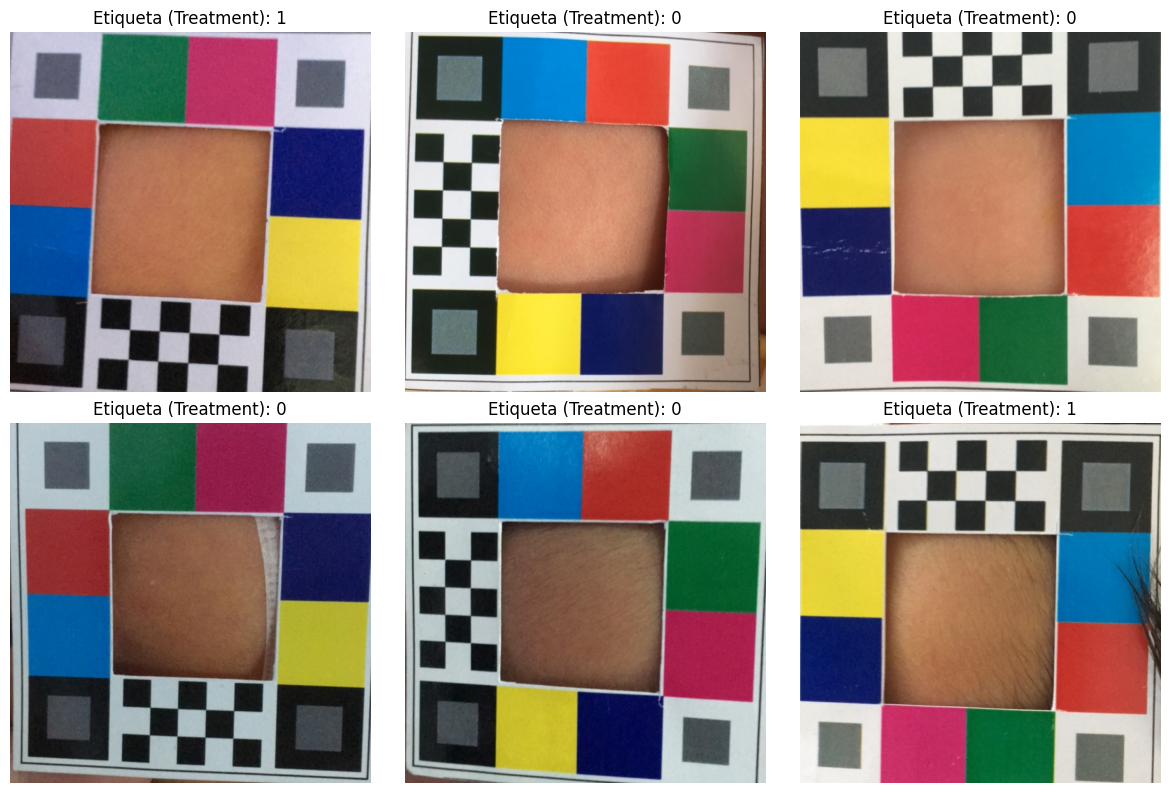

In [2]:
# Ruta a la carpeta que contiene las imágenes
ruta_imagenes = 'images'

# Cargar CSV con etiquetas y metadatos
csv_path = '/content/chd_jaundice_published_2.csv'

print(f"Dataset cargado con {len(df)} filas")

# Función para cargar imagen y su etiqueta
def cargar_imagen_y_etiqueta(row):
    nombre_archivo = row['image_idx']
    etiqueta = row['Treatment']
    ruta_imagen = os.path.join(ruta_imagenes, nombre_archivo)
    imagen = cv2.imread(ruta_imagen)
    if imagen is not None:
        imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
        return imagen_rgb, etiqueta
    else:
        print(f"No se pudo cargar la imagen: {ruta_imagen}")
        return None, etiqueta

# Mostrar 6 ejemplos aleatorios con sus etiquetas
import random
muestras = random.sample(range(len(df)), 6)

plt.figure(figsize=(12,8))
for i, idx in enumerate(muestras):
    imagen, etiqueta = cargar_imagen_y_etiqueta(df.iloc[idx])
    if imagen is not None:
        plt.subplot(2,3,i+1)
        plt.imshow(imagen)
        plt.title(f"Etiqueta (Treatment): {etiqueta}")
        plt.axis('off')
plt.tight_layout()
plt.show()


# Modelo claisficacio con ETL y balance de colores (78% accuracy)


Se procede a balancear el color de el dataseten base a la tarjeta de color, se opto por un balance en escala de grises.
Luego se genera un recorte de la parte central de la imagen correspondiente al segmento de piel y se asocia a su metadata del csv para tener un conjunto de datos etiquetados listo para entrenar al modelo

In [3]:
# Cargar CSV original
df = pd.read_csv('/content/chd_jaundice_published_2.csv')

# Crear carpeta para los parches si no existe
os.makedirs("/content/parches_150x150", exist_ok=True)

def balance_blancos_por_grises(img_rgb):
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    lower_gray = np.array([0, 0, 50])
    upper_gray = np.array([180, 50, 255])
    mask_gray = cv2.inRange(hsv, lower_gray, upper_gray)
    contours, _ = cv2.findContours(mask_gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidate_patches = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h)
        area = cv2.contourArea(cnt)
        if 0.8 < aspect_ratio < 1.2 and area > 100:
            patch = img_rgb[y:y+h, x:x+w]
            candidate_patches.append(patch.reshape(-1,3))
    if len(candidate_patches) == 0:
        return img_rgb
    all_gray_pixels = np.concatenate(candidate_patches, axis=0)
    patch_mean_rgb = np.mean(all_gray_pixels, axis=0)
    gain = 255 / patch_mean_rgb
    img_balanced = np.clip(img_rgb * gain, 0, 255).astype(np.uint8)
    return img_balanced

# Generación de parches y CSV final con columnas extra
nueva_data = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    ruta_imagen = "/content/images/" + row['image_idx']
    etiqueta = int(row['Treatment'])
    img = cv2.imread(ruta_imagen)
    if img is None:
        print(f"No se pudo leer {ruta_imagen}")
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Balance de blancos
    img_corr = balance_blancos_por_grises(img_rgb)

    # Recorte del centro (150x150)
    h, w, _ = img_corr.shape
    centro_x = w // 2
    centro_y = h // 2
    x1 = max(0, centro_x - 75)
    y1 = max(0, centro_y - 75)
    x2 = x1 + 150
    y2 = y1 + 150
    parche = img_corr[y1:y2, x1:x2]

    # Guardar parche
    nombre_patch = f"/content/parches_150x150/{row['image_idx'].replace('.jpg','')}_patch.jpg"
    cv2.imwrite(nombre_patch, cv2.cvtColor(parche, cv2.COLOR_RGB2BGR))

    # Guardar en CSV nuevo con columnas extra
    nueva_data.append({
        'image_patch': nombre_patch,
        'label': etiqueta,
        'patient_id': row['patient_id'],
        'gender': row['gender'],
        'gestational_age': row['gestational_age'],
        'age(day)': row['age(day)'],
        'weight': row['weight'],
        'blood(mg/dL)': row['blood(mg/dL)']
    })

# Guardar CSV final con todos los datos
df_parches = pd.DataFrame(nueva_data)
df_parches.to_csv('/content/dataset_patches_150x150_con_info.csv', index=False)

print("\n✅ Parches 150x150 generados y CSV con info extra creado en '/content/dataset_patches_150x150_con_info.csv'")


100%|██████████| 2235/2235 [01:29<00:00, 24.87it/s]



✅ Parches 150x150 generados y CSV con info extra creado en '/content/dataset_patches_150x150_con_info.csv'


In [4]:
# Cargar CSV de parches con info extra (usaremos solo image_patch y label para ML clásico)
df_parches = pd.read_csv('/content/dataset_patches_150x150_con_info.csv')

# Cargar todas las imágenes de parches y aplanarlas
X = []
y = []

for idx, row in tqdm(df_parches.iterrows(), total=len(df_parches)):
    img = cv2.imread(row['image_patch'])
    if img is None:
        print(f"No se pudo leer {row['image_patch']}")
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_flat = img_rgb.flatten()  # Aplanar para ML clásico
    X.append(img_flat)
    y.append(row['label'])

X = np.array(X)
y = np.array(y)

print(f"Shape final del dataset de features: {X.shape}")

# Normalizar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split Train-Test con stratify para balancear clases
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Entrenamiento del modelo Random Forest
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Predicción
y_pred = modelo.predict(X_test)

# Evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print(f"\nAccuracy general: {accuracy_score(y_test, y_pred):.2f}")


100%|██████████| 2235/2235 [00:01<00:00, 1853.57it/s]


Shape final del dataset de features: (2235, 67500)

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       260
           1       0.75      0.69      0.72       187

    accuracy                           0.78       447
   macro avg       0.77      0.76      0.77       447
weighted avg       0.78      0.78      0.77       447


Matriz de confusión:
[[218  42]
 [ 58 129]]

Accuracy general: 0.78


In [5]:
import joblib

# Guardar el modelo
joblib.dump(modelo, '/content/modelo_rf.pkl')

# Guardar el scaler
joblib.dump(scaler, '/content/scaler.pkl')

print("✅ Modelo y scaler guardados correctamente.")


✅ Modelo y scaler guardados correctamente.


Conseguimos una eficiencia del 78% habiendo partido de una del 61% sin un debido balance de colores, tambien optamos por aplicar redes convulcionales pero el resultado fue exactamente el mismo 78% al intentar ampliar el volumen del dataset con datos sinteticos los resultados fueron empeorando por lo que optamos por quedarnos con el modelo mas simple de clasificacion por una cuestion de costo beneficio

# Segmentacion y guardado de patch del cuerpo

Tomamos la foto a anlizar y le hacemos un balance de blancos en este caso nos ayuda mucho si el fondo de la imagen es de este color ya que no es prudente exigirle a el usuario una tarjeta de color para un balance mas optimo.
Luego procedemos a identificar los puntos del cuerpo con la libreria "mediapipe" tomando 4 de cada seccion analizada en la tabla de kramer (cabeza, toros superior, torso inferior, extremidades) para no quedarnos con una unica muestra de color a comparar y poder tener resultados mas robustos.
Los puntos identificados son guardados en una carpeta en la medida y formato adecuados para que el modelo pueda trabajar con ellos.

In [ ]:
# --- Función para balance de blancos con fondo blanco ---
def balance_blancos_fondo_blanco(img_rgb):
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    mask_white = cv2.inRange(hsv, (0, 0, 200), (180, 50, 255))
    white_pixels = img_rgb[mask_white > 0]
    if len(white_pixels) < 50:
        print("⚠️ No se encontró suficiente fondo blanco para hacer balance.")
        return img_rgb
    mean_white = np.mean(white_pixels, axis=0)
    gain = 255 / mean_white
    img_corr = np.clip(img_rgb * gain, 0, 255).astype(np.uint8)
    return img_corr

# --- Configuración Inicial ---
image_path = '/content/bebe.jpeg'
output_dir = '/content/patches_extraidos'
os.makedirs(output_dir, exist_ok=True)
default_patch_size = 10

# Inicializar MediaPipe
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

# Cargar imagen
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Aplicar balance de blancos
img_rgb = balance_blancos_fondo_blanco(img_rgb)

h, w, _ = img.shape

# Procesar pose
results = pose.process(img_rgb)
if not results.pose_landmarks:
    print("No se detectaron landmarks.")
    exit()

landmarks = results.pose_landmarks.landmark

# --- Funciones útiles ---
def get_xy(index):
    lm = landmarks[index]
    return int(lm.x * w), int(lm.y * h)

def mid_point(idx1, idx2):
    x1, y1 = get_xy(idx1)
    x2, y2 = get_xy(idx2)
    return ((x1 + x2) // 2, (y1 + y2) // 2)

def crop_patch(center, size=default_patch_size):
    cx, cy = center
    half = size // 2
    x1 = max(cx - half, 0)
    y1 = max(cy - half, 0)
    x2 = min(cx + half, w)
    y2 = min(cy + half, h)
    return img_rgb[y1:y2, x1:x2]

def crop_polygon_centered_square(puntos):
    xs = [p[0] for p in puntos]
    ys = [p[1] for p in puntos]
    x1, y1 = max(min(xs), 0), max(min(ys), 0)
    x2, y2 = min(max(xs), w), min(max(ys), h)

    ancho = x2 - x1
    alto = y2 - y1
    lado = min(ancho, alto)

    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2
    half = lado // 2

    x1_sq = max(cx - half, 0)
    y1_sq = max(cy - half, 0)
    x2_sq = min(cx + half, w)
    y2_sq = min(cy + half, h)

    return img_rgb[y1_sq:y2_sq, x1_sq:x2_sq]

def guardar_patch(patch, nombre):
    path = os.path.join(output_dir, nombre)
    cv2.imwrite(path, cv2.cvtColor(patch, cv2.COLOR_RGB2BGR))

# --- Secciones y Puntos ---
puntos_total = []

# Cabeza (1,3,5,7)
cabeza_pts = [get_xy(idx) for idx in [1,3,5,7]]
puntos_total.extend(cabeza_pts)

# Torso Superior (13,14 + 2 intermedios entre 11 y 12)
p13, p14 = get_xy(13), get_xy(14)
p11, p12 = get_xy(11), get_xy(12)
mid1 = (
    int(p11[0] + (p12[0] - p11[0]) * 0.33),
    int(p11[1] + (p12[1] - p11[1]) * 0.33)
)
mid2 = (
    int(p11[0] + (p12[0] - p11[0]) * 0.66),
    int(p11[1] + (p12[1] - p11[1]) * 0.66)
)
torso_sup_pts = [p13, p14, mid1, mid2]
puntos_total.extend(torso_sup_pts)

# Torso Inferior
torso_inf_pts = [
    mid_point(24,26),
    mid_point(26,28),
    mid_point(23,25),
    mid_point(25,27)
]
puntos_total.extend(torso_inf_pts)

# Manos y pies
mano_izq_pts = [get_xy(i) for i in [15,17,19,21]]
mano_der_pts = [get_xy(i) for i in [16,18,20,22]]
pie_izq_pts = [get_xy(i) for i in [27,29,31]]
pie_der_pts = [get_xy(i) for i in [28,30,32]]

# --- Guardar parches ---

# Cabeza, Torso Superior, Torso Inferior
secciones = [
    ('cabeza', cabeza_pts, 10),
    ('torso_sup', torso_sup_pts, 10),
    ('torso_inf', torso_inf_pts, 10)
]

for seccion, puntos, size in secciones:
    for idx, punto in enumerate(puntos):
        patch = crop_patch(punto, size=size)
        guardar_patch(patch, f'patch_{seccion}_{idx+1}.jpg')

# Manos y pies (recorte cuadrado dentro del polígono)
for nombre, pts in [
    ('mano_izq', mano_izq_pts),
    ('mano_der', mano_der_pts),
    ('pie_izq', pie_izq_pts),
    ('pie_der', pie_der_pts)
]:
    patch = crop_polygon_centered_square(pts)
    guardar_patch(patch, f'patch_{nombre}.jpg')

print(f"✅ Todos los parches fueron guardados en: {output_dir}")


✅ Todos los parches fueron guardados en: /content/patches_extraidos


# Ejecucion del modelo y resultados

El modelo toma todos los paths generados de la imagen para compararlos con su entrenamiento y determinar si cada punto corresponde a una coloracion de ictericia o no.
Luego los resultados son clasificados con un critero de si 3 de los 4 puntos corresponden a una coloracion de ictericia se considera que esa seccion del cuerpo tiene la afeccion.
Esta en contemplacion bajar este numero a 2 de 4 ya que creemos que es mejor dar un falso positivo que lo opuesto pero nos gustaria tener la ascesoria de un profesional de la medicina respecto a la situacion.

/tmp/ipython-input-31-2050455084.py:18: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-31-2050455084.py:18: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


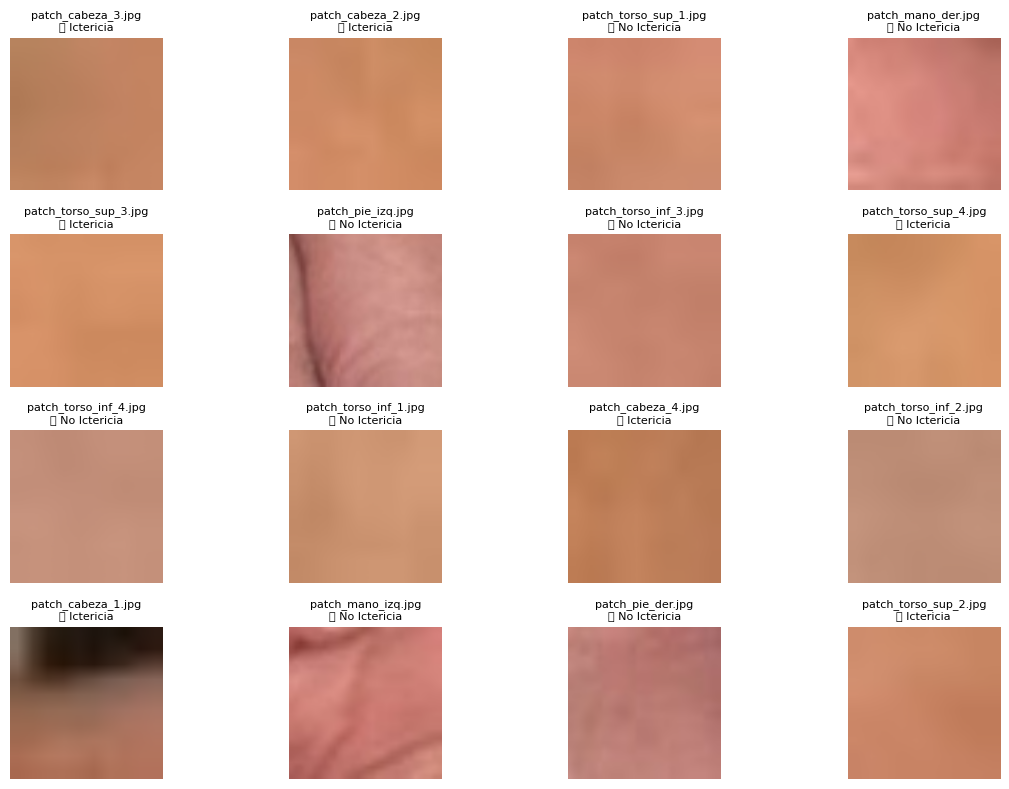

In [ ]:
# Predecir
predicciones = modelo.predict(X_new_scaled)

# Mostrar cada imagen + resultado
plt.figure(figsize=(12, 8))

for i, (nombre, img_flat, pred) in enumerate(zip(nombres_patches, X_new, predicciones)):
    img_patch = img_flat.reshape((150, 150, 3)).astype(np.uint8)  # Volver a forma de imagen

    plt.subplot(4, 4, i+1)  # Ajusta 4x4 o más según cantidad
    plt.imshow(img_patch)
    resultado = "✅ Ictericia" if pred == 1 else "❌ No Ictericia"
    plt.title(f"{nombre}\n{resultado}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Clasificar resultados por sección
niveles = {
    "nivel_1_cabeza": 0,
    "nivel_2_torso_sup": 0,
    "nivel_3_torso_inf": 0,
    "nivel_4_manos_pies": 0
}

print("\n🔎 Resultados por patch:")
for nombre, pred in zip(nombres_patches, predicciones):
    resultado = "Ictericia" if pred == 1 else "No Ictericia"
    print(f"{nombre}: {resultado}")

    if pred == 1:
        if "cabeza" in nombre:
            niveles["nivel_1_cabeza"] += 1
        elif "torso_sup" in nombre:
            niveles["nivel_2_torso_sup"] += 1
        elif "torso_inf" in nombre:
            niveles["nivel_3_torso_inf"] += 1
        elif ("mano" in nombre) or ("pie" in nombre):
            niveles["nivel_4_manos_pies"] += 1

# Diagnóstico por niveles
print("\n📋 Diagnóstico por niveles:")

if niveles["nivel_1_cabeza"] >= 3:
    print("Nivel 1: Ictericia detectada en la cabeza")

if niveles["nivel_2_torso_sup"] >= 3:
    print("Nivel 2: Ictericia detectada en el torso superior")

if niveles["nivel_3_torso_inf"] >= 3:
    print("Nivel 3: Ictericia detectada en el torso inferior")

if niveles["nivel_4_manos_pies"] >= 3:
    print("Nivel 4: Ictericia detectada en extremidades (manos/pies)")


🔎 Resultados por patch:
patch_cabeza_3.jpg: Ictericia
patch_cabeza_2.jpg: Ictericia
patch_torso_sup_1.jpg: No Ictericia
patch_mano_der.jpg: No Ictericia
patch_torso_sup_3.jpg: Ictericia
patch_pie_izq.jpg: No Ictericia
patch_torso_inf_3.jpg: No Ictericia
patch_torso_sup_4.jpg: Ictericia
patch_torso_inf_4.jpg: No Ictericia
patch_torso_inf_1.jpg: No Ictericia
patch_cabeza_4.jpg: Ictericia
patch_torso_inf_2.jpg: No Ictericia
patch_cabeza_1.jpg: Ictericia
patch_mano_izq.jpg: No Ictericia
patch_pie_der.jpg: No Ictericia
patch_torso_sup_2.jpg: Ictericia

📋 Diagnóstico por niveles:
Nivel 1: Ictericia detectada en la cabeza
Nivel 2: Ictericia detectada en el torso superior


# Pipeline final


Reunimos todo el proceso en un pipeline para la ejecucion de todo el proceso de forma simple y accesible para el usuario final.

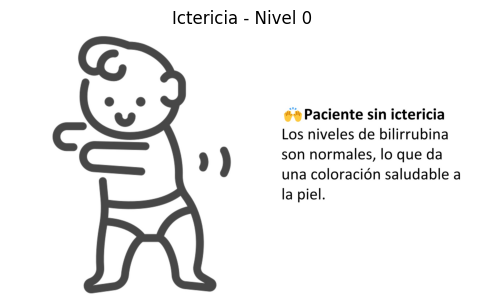

In [30]:
import os
import cv2
import numpy as np
import joblib
import mediapipe as mp
from sklearn.preprocessing import StandardScaler
from google.colab import files
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

# Cargar modelo y scaler
modelo = joblib.load('/content/modelo_rf.pkl')
scaler = joblib.load('/content/scaler.pkl')

# Balance de blancos
def balance_blancos_fondo_blanco(img_rgb):
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    mask_white = cv2.inRange(hsv, (0, 0, 200), (180, 50, 255))
    white_pixels = img_rgb[mask_white > 0]
    if len(white_pixels) < 50:
        return img_rgb
    mean_white = np.mean(white_pixels, axis=0)
    gain = 255 / mean_white
    img_corr = np.clip(img_rgb * gain, 0, 255).astype(np.uint8)
    return img_corr

def procesar_imagen(uploaded_file):
    # Guardar archivo temporal
    image_path = uploaded_file

    # Directorio de parches
    output_dir = '/content/patches_extraidos'
    os.makedirs(output_dir, exist_ok=True)

    # Inicializar mediapipe
    mp_pose = mp.solutions.pose
    pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

    # Cargar imagen
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = balance_blancos_fondo_blanco(img_rgb)
    h, w, _ = img.shape
    results = pose.process(img_rgb)
    if not results.pose_landmarks:
        print("❌ No se detectaron landmarks.")
        return

    landmarks = results.pose_landmarks.landmark

    def get_xy(index):
        lm = landmarks[index]
        return int(lm.x * w), int(lm.y * h)

    def mid_point(idx1, idx2):
        x1, y1 = get_xy(idx1)
        x2, y2 = get_xy(idx2)
        return ((x1 + x2) // 2, (y1 + y2) // 2)

    def crop_patch(center, size=10):
        cx, cy = center
        half = size // 2
        x1 = max(cx - half, 0)
        y1 = max(cy - half, 0)
        x2 = min(cx + half, w)
        y2 = min(cy + half, h)
        return img_rgb[y1:y2, x1:x2]

    def crop_polygon_centered_square(puntos):
        xs = [p[0] for p in puntos]
        ys = [p[1] for p in puntos]
        x1, y1 = max(min(xs), 0), max(min(ys), 0)
        x2, y2 = min(max(xs), w), min(max(ys), h)
        ancho = x2 - x1
        alto = y2 - y1
        lado = min(ancho, alto)
        cx = (x1 + x2) // 2
        cy = (y1 + y2) // 2
        half = lado // 2
        x1_sq = max(cx - half, 0)
        y1_sq = max(cy - half, 0)
        x2_sq = min(cx + half, w)
        y2_sq = min(cy + half, h)
        return img_rgb[y1_sq:y2_sq, x1_sq:x2_sq]

    def guardar_patch(patch, nombre):
        path = os.path.join(output_dir, nombre)
        cv2.imwrite(path, cv2.cvtColor(patch, cv2.COLOR_RGB2BGR))

    # --- Extraer parches ---
    cabeza_pts = [get_xy(i) for i in [1,3,5,7]]
    for idx, p in enumerate(cabeza_pts):
        guardar_patch(crop_patch(p, size=10), f'patch_cabeza_{idx+1}.jpg')

    p13, p14 = get_xy(13), get_xy(14)
    p11, p12 = get_xy(11), get_xy(12)
    mid1 = (int(p11[0] + (p12[0] - p11[0]) * 0.33), int(p11[1] + (p12[1] - p11[1]) * 0.33))
    mid2 = (int(p11[0] + (p12[0] - p11[0]) * 0.66), int(p11[1] + (p12[1] - p11[1]) * 0.66))
    torso_sup_pts = [p13, p14, mid1, mid2]
    for idx, p in enumerate(torso_sup_pts):
        guardar_patch(crop_patch(p, size=10), f'patch_torso_sup_{idx+1}.jpg')

    torso_inf_pts = [
        mid_point(24,26),
        mid_point(26,28),
        mid_point(23,25),
        mid_point(25,27)
    ]
    for idx, p in enumerate(torso_inf_pts):
        guardar_patch(crop_patch(p, size=10), f'patch_torso_inf_{idx+1}.jpg')

    manos_pies = [
        ('mano_izq', [get_xy(i) for i in [15,17,19,21]]),
        ('mano_der', [get_xy(i) for i in [16,18,20,22]]),
        ('pie_izq', [get_xy(i) for i in [27,29,31]]),
        ('pie_der', [get_xy(i) for i in [28,30,32]])
    ]
    for nombre, pts in manos_pies:
        guardar_patch(crop_polygon_centered_square(pts), f'patch_{nombre}.jpg')

    # --- Inferencia ---
    X_new = []
    nombres_patches = []
    target_size = (150, 150)

    for filename in os.listdir(output_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(output_dir, filename)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img_rgb = cv2.cvtColor(cv2.resize(img, target_size), cv2.COLOR_BGR2RGB)
            img_flat = img_rgb.flatten()
            X_new.append(img_flat)
            nombres_patches.append(filename)

    X_new = np.array(X_new)
    X_new_scaled = scaler.transform(X_new)
    predicciones = modelo.predict(X_new_scaled)

    # --- Conteo por zonas ---
    niveles = {'cabeza': 0, 'torso_sup': 0, 'torso_inf': 0, 'extremidades': 0}

    for nombre, pred in zip(nombres_patches, predicciones):
        if pred == 1:
            if nombre.startswith('patch_cabeza'):
                niveles['cabeza'] += 1
            elif nombre.startswith('patch_torso_sup'):
                niveles['torso_sup'] += 1
            elif nombre.startswith('patch_torso_inf'):
                niveles['torso_inf'] += 1
            elif nombre.startswith('patch_mano') or nombre.startswith('patch_pie'):
                niveles['extremidades'] += 1

    # --- Diagnóstico final NO acumulativo ---
    if niveles['extremidades'] >= 3:
        nivel = 4
    elif niveles['torso_inf'] >= 3:
        nivel = 3
    elif niveles['torso_sup'] >= 3:
        nivel = 2
    elif niveles['cabeza'] >= 3:
        nivel = 1
    else:
        nivel = 0

    # --- Mostrar imagen del nivel ---
    img_path_final = f'/content/ilustraciones/nivel{nivel}.jpg'
    clear_output()
    try:
        img = Image.open(img_path_final)
        plt.figure(figsize=(6, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'Ictericia - Nivel {nivel}')
        plt.show()
    except FileNotFoundError:
        print(f"⚠️ No se encontró la imagen: {img_path_final}")

# --- Botón para subir imagen y ejecutar ---
upload_button = widgets.FileUpload(accept='.jpg,.jpeg,.png', multiple=False)
run_button = widgets.Button(description='Procesar Imagen')

def on_run_button_clicked(b):
    if upload_button.value:
        filename = list(upload_button.value.keys())[0]
        with open(filename, 'wb') as f:
            f.write(upload_button.value[filename]['content'])
        procesar_imagen(filename)
    else:
        print("⚠️ Por favor sube una imagen primero.")

run_button.on_click(on_run_button_clicked)

display(widgets.HTML("<h3>Subí una imagen de paciente y presioná el botón:</h3>"))
display(upload_button, run_button)


# Interfaz con Gradio


In [31]:
!pip install gradio


In [33]:
import gradio as gr
import cv2
import numpy as np
from PIL import Image
import joblib
import os
import matplotlib.pyplot as plt

# Cargar tu modelo y scaler
modelo = joblib.load('/content/modelo_rf.pkl')
scaler = joblib.load('/content/scaler.pkl')

def analizar_ictericia(input_image):
    # Guardar imagen temporal
    image_path = "/content/temp_image.jpg"
    input_image.save(image_path)

    # TODO: Acá va tu código completo de extracción de parches, balance de blancos, procesamiento, etc.
    # Que termine calculando el nivel (0-4) según el conteo de parches positivos

    ### Simulación rápida de salida (reemplazalo por tu lógica real):
    nivel = np.random.choice([0, 1, 2, 3, 4])  # Ejemplo random

    # Cargar imagen de ilustración
    nivel_img_path = f"/content/ilustraciones/nivel{nivel}.g"
    if os.path.exists(nivel_img_path):
        result_img = Image.open(nivel_img_path)
    else:
        result_img = Image.new("RGB", (300, 300), color="red")

    return result_img

# Crear interfaz Gradio
iface = gr.Interface(
    fn=analizar_ictericia,
    inputs=gr.Image(type="pil"),
    outputs=gr.Image(type="pil"),
    title="Detección de Ictericia en Neonatos",
    description="Subí una foto y el modelo te mostrará la zona afectada."
)

iface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f767fefc9c774ede3f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
